In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import shap

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

In [5]:
df.shape

(32581, 12)

In [6]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

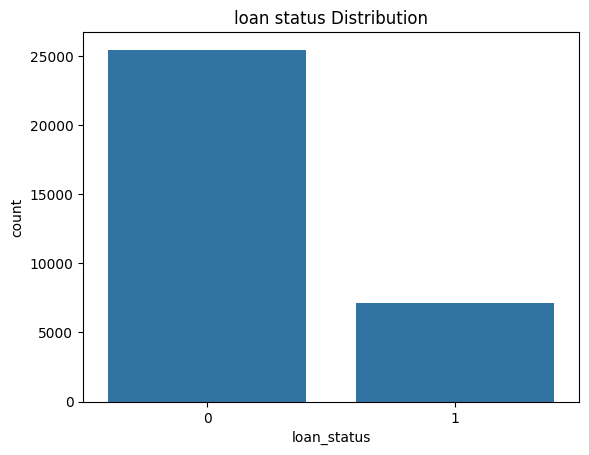

In [7]:
sns.countplot(x="loan_status", data=df)
plt.title("loan status Distribution")
plt.show()

In [8]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [9]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["loan_int_rate"].sort_values(ascending=False)

loan_int_rate                 1.000000
loan_status                   0.335133
loan_amnt                     0.146813
loan_percent_income           0.120314
cb_person_cred_hist_length    0.016696
person_age                    0.012580
person_income                 0.000792
person_emp_length            -0.056405
Name: loan_int_rate, dtype: float64

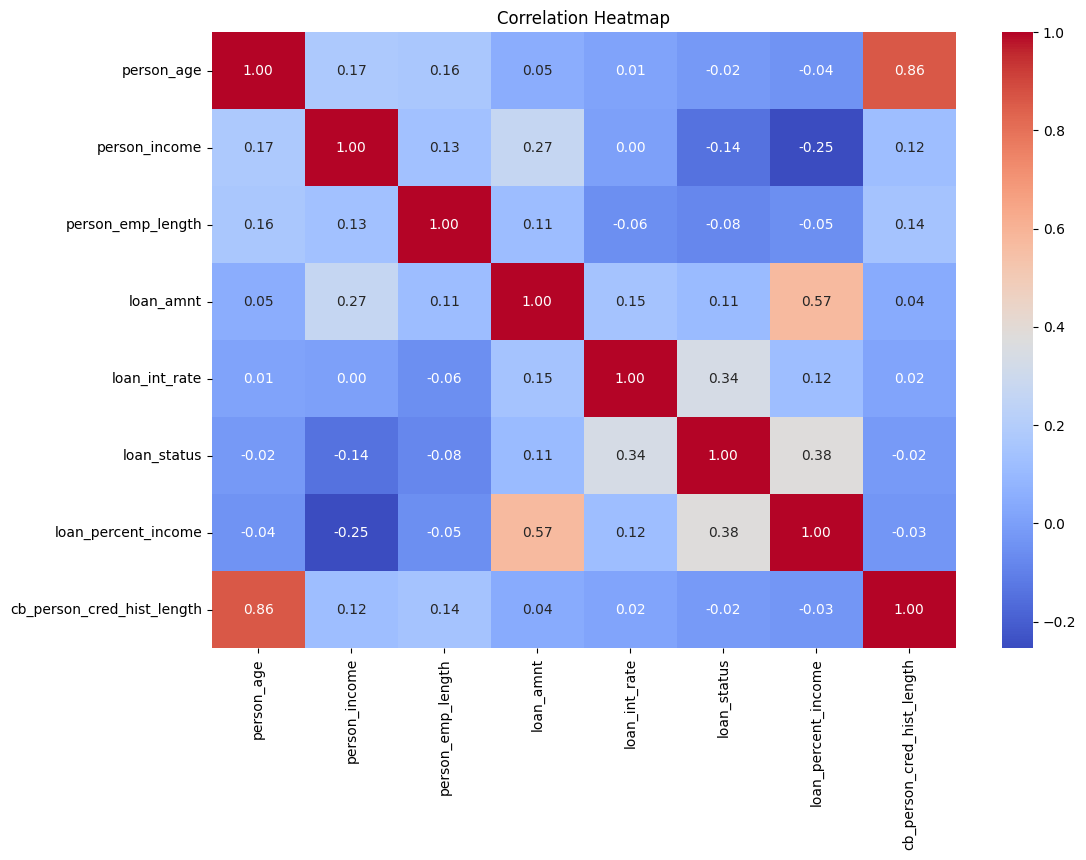

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [11]:
df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

In [12]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [13]:
df.select_dtypes(include="string").columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='str')

In [14]:
for col in df.select_dtypes(include="string").columns:
    print(col)
    print(df[col].unique())
    print()

person_home_ownership
<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent
<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

loan_grade
<ArrowStringArray>
['D', 'B', 'C', 'A', 'E', 'F', 'G']
Length: 7, dtype: str

cb_person_default_on_file
<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str



In [15]:
grade_mapping = {
    'A':1,
    'B':2,
    'C':3,
    'D':4,
    'E':5,
    'F':6,
    'G':7
}

In [19]:
default_mapping={
 'N':0,
 'Y':1
}

In [20]:
X = df.drop("loan_status", axis=1)

y = df["loan_status"]

In [21]:
X["loan_grade"] = X["loan_grade"].map(grade_mapping)

X["cb_person_default_on_file"] = X[
    "cb_person_default_on_file"
].map(default_mapping)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [24]:
categorical_cols = [
    "person_home_ownership",
    "loan_intent"
]

ordinal_cols = [
    "loan_grade",
    "cb_person_default_on_file"
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols + ordinal_cols
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.pipeline import Pipeline

In [27]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [32]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [33]:
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5095
           1       0.98      0.72      0.83      1422

    accuracy                           0.94      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0.94      0.94      0.93      6517



In [34]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [35]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5072   23]
 [ 400 1022]]


In [36]:
y_prob = pipeline.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

0.9320303819552276

In [41]:
y_prob = pipeline.predict_proba(X_test)[:,1]

y_pred_40 = (y_prob >= 0.4).astype(int)

print(classification_report(y_test, y_pred_40))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.94      0.74      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.93      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



In [42]:
encoded_features = pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

print(encoded_features)

['cat__person_home_ownership_MORTGAGE' 'cat__person_home_ownership_OTHER'
 'cat__person_home_ownership_OWN' 'cat__person_home_ownership_RENT'
 'cat__loan_intent_DEBTCONSOLIDATION' 'cat__loan_intent_EDUCATION'
 'cat__loan_intent_HOMEIMPROVEMENT' 'cat__loan_intent_MEDICAL'
 'cat__loan_intent_PERSONAL' 'cat__loan_intent_VENTURE'
 'remainder__person_age' 'remainder__person_income'
 'remainder__person_emp_length' 'remainder__loan_grade'
 'remainder__loan_amnt' 'remainder__loan_int_rate'
 'remainder__loan_percent_income' 'remainder__cb_person_default_on_file'
 'remainder__cb_person_cred_hist_length']


In [43]:
importances = pipeline.named_steps[
    "model"
].feature_importances_

In [44]:
feature_importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
16,remainder__loan_percent_income,0.222494
11,remainder__person_income,0.145974
13,remainder__loan_grade,0.113677
15,remainder__loan_int_rate,0.112406
14,remainder__loan_amnt,0.074049
12,remainder__person_emp_length,0.060037
3,cat__person_home_ownership_RENT,0.049577
10,remainder__person_age,0.044937
18,remainder__cb_person_cred_hist_length,0.033384
0,cat__person_home_ownership_MORTGAGE,0.030382


In [46]:
import joblib
joblib.dump(
    pipeline,
    "loan_default_model.pkl"
)

['loan_default_model.pkl']

In [47]:
loaded_model = joblib.load(
    "loan_default_model.pkl"
)

In [48]:
sample = X_test.iloc[[0]]

sample

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
6616,22,50000,RENT,6.0,PERSONAL,2,6000,11.89,0.12,0,2


In [49]:
loaded_model.predict(sample)

array([0])

In [50]:
loaded_model.predict_proba(sample)

array([[0.92, 0.08]])

In [53]:
def predict_loan_risk(
    age,
    income,
    home_ownership,
    emp_length,
    loan_intent,
    loan_grade,
    loan_amount,
    interest_rate,
    previous_default,
    credit_history_length
):

    loan_grade = grade_mapping[loan_grade]
    previous_default = default_mapping[previous_default]

    loan_percent_income = loan_amount / income

    data = pd.DataFrame({
        "person_age": [age],
        "person_income": [income],
        "person_home_ownership": [home_ownership],
        "person_emp_length": [emp_length],
        "loan_intent": [loan_intent],
        "loan_grade": [loan_grade],
        "loan_amnt": [loan_amount],
        "loan_int_rate": [interest_rate],
        "loan_percent_income": [loan_percent_income],
        "cb_person_default_on_file": [previous_default],
        "cb_person_cred_hist_length": [credit_history_length]
    })

    prediction = loaded_model.predict(data)[0]
    probability = loaded_model.predict_proba(data)[0][1]

    return prediction, probability

In [54]:
prediction, prob = predict_loan_risk(
    age=30,
    income=60000,
    home_ownership="RENT",
    emp_length=5,
    loan_intent="PERSONAL",
    loan_grade="B",
    loan_amount=10000,
    interest_rate=12,
    previous_default="N",
    credit_history_length=8
)

print(prediction)
print(prob)


0
0.07


In [55]:
X_test_transformed = pipeline.named_steps[
    "preprocessor"
].transform(X_test)

In [56]:
explainer = shap.TreeExplainer(
    pipeline.named_steps["model"]
)

In [57]:
shap_values = explainer.shap_values(
    X_test_transformed
)

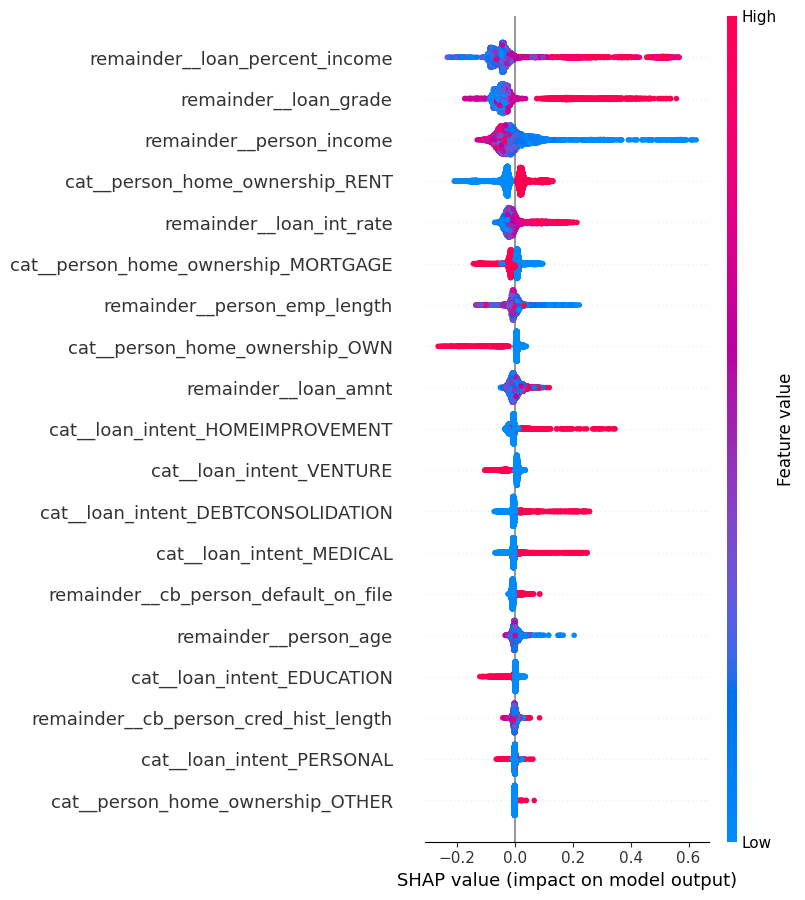

In [58]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test_transformed,
    feature_names=pipeline.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

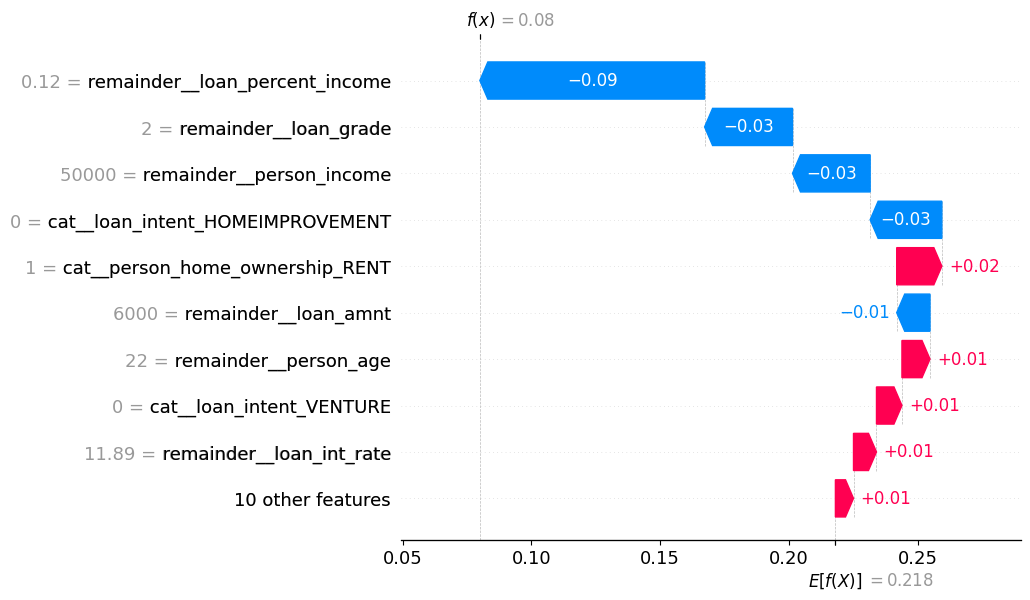

In [59]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index,:,1],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[sample_index],
        feature_names=pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )
)